# Iterative Matched Filter + two-direction diagonal destriping 改良版

この notebook は、Iterative MF の `alpha_map` に対して、

1. `y=x` 方向、つまり `row - col = const`
2. その後に `y=-x` 方向、つまり `row + col = const`

の順で stripe offset を推定して差し引く版です。

`y=x` 方向だけでなく、スワス方向に相当するもう一方の diagonal 方向にも補正を入れたい場合に使います。

主な機能:

- `final_only`: Iterative MF を回した後の最終 `alpha_map` にだけ 2方向 destriping
- `each_iter`: 各 iteration の plume 判定前に 2方向 destriping
- `[3,4,5]`: 指定 iteration だけ 2方向 destriping
- `median`, `mean`, `trimmed_mean`, `mode` を切替可能
- `directions=["y_minus_x", "y_plus_x"]` で、`y=x` → `y=-x` の順に補正
- 各方向の stripe map と line table を保存
- high-alpha / plume 候補の除外、fallback、line offset smoothing に対応

**注意:** 2方向補正は強力なので、本物の plume が細長く伸びている場合、その一部も背景 stripe として引かれる可能性があります。必ず `stripe_map` と補正前後の `alpha_map` を見比べてください。



In [12]:
# ============================================
# 0. Imports and user settings
# ============================================
from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, Sequence, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Input files
# ----------------------------
# ROI CSV: columns = y, x, wave_XXXXnm, wave_XXXXnm, ...
ROI_CSV = Path("all_roi_spectra200x200.csv")

# MODTRAN CSV: columns = wavelength, 0.0, 0.5, 1.0, ...
MODTRAN_CSV = Path("E:\\refit\\CH4c.csv")

OUTPUT_DIR = Path("outputs_two_direction_diagonal_destripe")

# ----------------------------
# Wavelength / UAS settings
# ----------------------------
WL_MIN = 2100.0
WL_MAX = 2450.0
FWHM_NM = 12.5

# UAS を作る alpha 範囲。元 notebook と同様に low-alpha を使う設定。
UAS_ALPHA_MIN = 0.0
UAS_ALPHA_MAX = 0.5

# ----------------------------
# Iterative MF settings
# ----------------------------
N_ITER = 5
NSIGMA = 3.0   # 4.0 に戻したい場合はここを変更
REG = 1e-6
RCOND = 1e-8

# ----------------------------
# Valid pixel settings
# ----------------------------
NODATA_VALUES = [0, -9999]
REQUIRE_POSITIVE = True
MIN_VALID_FRACTION = 1.0

# ----------------------------
# Recommended destriping parameters
# ----------------------------
DEFAULT_DESTRIPE_PARAMS = {
    # 補正する方向。
    # y=x 方向:     "y_minus_x" -> row - col = const
    # y=-x 方向:    "y_plus_x"  -> row + col = const
    # ここでは、y=x を先に補正し、その後 y=-x を補正する。
    "directions": ["y_minus_x", "y_plus_x"],

    # "median", "mean", "trimmed_mean", "mode"
    "method": "median",

    # diagonal 1本あたり最低何画素あれば offset を推定するか
    "min_pixels_per_line": 5,

    # True: line_stat - global_stat を引く。alpha 全体の基準値を保ちやすい。
    # False: line_stat をそのまま引く。
    "preserve_global_stat": True,

    # 隣接 diagonal の offset を median smoothing する半窓。まずは 0, 1, 2 を試す。
    "smooth_half_window": 0,

    # 除外モード:
    # "none", "robust_high", "previous_plume", "previous_plume_or_high"
    # 今回の線状 artifact 自体が plume 候補に入る場合は、"previous_plume" より
    # "robust_high" または "none" の方が効くことがあります。
    "exclude_mode": "robust_high",
    "exclude_nsigma": NSIGMA,

    # 2方向目の補正時に、1方向目で補正された alpha_map から exclude mask を再計算する。
    # True 推奨。
    "recompute_exclude_each_direction": True,

    # 除外後に diagonal の画素数が足りないとき、valid pixel で再推定する。
    "fallback_to_valid": True,

    # trimmed_mean 用
    "trim_fraction": 0.1,

    # mode 用。連続値の mode は histogram 近似になるので bin 数依存。
    "mode_bins": 64,

    # each_iter の場合、補正後 alpha で plume 判定するか。
    # "corrected" 推奨。"raw" にすると補正は保存だけで mask 更新には使わない。
    "threshold_source": "corrected",
}

# ----------------------------
# Experiment settings
# ----------------------------
# destripe_when:
#   "none"       : destriping なし
#   "final_only" : N_ITER 後の alpha にだけ destriping
#   "each_iter"  : 各 iteration の alpha に destriping してから plume 判定
#   [3,4,5]      : 指定 iteration だけ destriping
EXPERIMENTS = {
    "baseline_no_destripe": {
        "destripe_when": "none",
        "destripe_params": None,
    },

    # y=x 方向のみ: 比較用
    "median_yx_final_only": {
        "destripe_when": "final_only",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "directions": ["y_minus_x"], "method": "median"},
    },
    "median_yx_each_iter": {
        "destripe_when": "each_iter",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "directions": ["y_minus_x"], "method": "median"},
    },

    # y=x -> y=-x の2方向補正: 本命
    "median_yx_then_ynegx_final_only": {
        "destripe_when": "final_only",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "median"},
    },
    "median_yx_then_ynegx_each_iter": {
        "destripe_when": "each_iter",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "median"},
    },

    # 統計量の比較用
    "mean_yx_then_ynegx_each_iter": {
        "destripe_when": "each_iter",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "mean"},
    },
    "trimmed_mean_yx_then_ynegx_each_iter": {
        "destripe_when": "each_iter",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "trimmed_mean"},
    },
    "mode_yx_then_ynegx_each_iter": {
        "destripe_when": "each_iter",
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "mode", "mode_bins": 64},
    },

    # 3回目以降だけ2方向補正
    "median_yx_then_ynegx_iter_3_to_5": {
        "destripe_when": [3, 4, 5],
        "destripe_params": {**DEFAULT_DESTRIPE_PARAMS, "method": "median"},
    },
}



In [2]:

# ============================================
# 1. Data loading helpers
# ============================================

def get_wave_columns(df: pd.DataFrame) -> tuple[list[str], np.ndarray]:
    """Return wavelength columns sorted by wavelength."""
    wave_cols: list[str] = []
    wavelengths: list[float] = []

    pattern = re.compile(r"^wave_([0-9]+(?:\.[0-9]+)?)nm$")
    for col in df.columns:
        match = pattern.match(col)
        if match is not None:
            wave_cols.append(col)
            wavelengths.append(float(match.group(1)))

    if len(wave_cols) == 0:
        raise ValueError("No wavelength columns like wave_2300nm were found.")

    wavelengths_arr = np.asarray(wavelengths, dtype=float)
    order = np.argsort(wavelengths_arr)
    wavelengths_arr = wavelengths_arr[order]
    wave_cols_sorted = [wave_cols[i] for i in order]
    return wave_cols_sorted, wavelengths_arr


def load_roi_spectra_csv(path: str | Path) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Load ROI spectra CSV with y, x, and wave_XXXXnm columns."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"ROI CSV not found: {path}")

    df = pd.read_csv(path)
    if "y" not in df.columns or "x" not in df.columns:
        raise ValueError("ROI CSV must contain columns 'y' and 'x'.")

    wave_cols, wavelengths = get_wave_columns(df)
    spectra = df[wave_cols].to_numpy(dtype=float)
    return df, wavelengths, spectra


def spectra_to_cube(
    df: pd.DataFrame,
    spectra: np.ndarray,
    fill_value: float = np.nan,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Convert table spectra to image cube [H, W, B]."""
    ys = np.sort(df["y"].unique())
    xs = np.sort(df["x"].unique())

    y_to_row = {y: i for i, y in enumerate(ys)}
    x_to_col = {x: j for j, x in enumerate(xs)}

    H, W = len(ys), len(xs)
    B = spectra.shape[1]
    cube = np.full((H, W, B), fill_value, dtype=float)

    for row_idx, row in df.iterrows():
        r = y_to_row[row["y"]]
        c = x_to_col[row["x"]]
        cube[r, c, :] = spectra[row_idx, :]

    return cube, ys, xs


def band_mask(
    wavelengths: np.ndarray,
    wl_min: Optional[float] = None,
    wl_max: Optional[float] = None,
    exclude_ranges: Optional[Sequence[tuple[float, float]]] = None,
) -> np.ndarray:
    mask = np.ones_like(wavelengths, dtype=bool)

    if wl_min is not None:
        mask &= wavelengths >= wl_min
    if wl_max is not None:
        mask &= wavelengths <= wl_max

    if exclude_ranges is not None:
        for a, b in exclude_ranges:
            mask &= ~((wavelengths >= a) & (wavelengths <= b))

    return mask


def select_bands(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    wl_min: float,
    wl_max: float,
    exclude_ranges: Optional[Sequence[tuple[float, float]]] = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    mask = band_mask(wavelengths, wl_min=wl_min, wl_max=wl_max, exclude_ranges=exclude_ranges)
    return cube[:, :, mask], wavelengths[mask], mask


In [3]:

# ============================================
# 2. Plotting helpers
# ============================================

def finite_values(img: np.ndarray, mask: Optional[np.ndarray] = None) -> np.ndarray:
    arr = np.asarray(img, dtype=float)
    if mask is None:
        vals = arr[np.isfinite(arr)]
    else:
        vals = arr[np.isfinite(arr) & np.asarray(mask, dtype=bool)]
    return vals


def robust_limits(
    images: Union[np.ndarray, Sequence[np.ndarray]],
    mask: Optional[np.ndarray] = None,
    q_low: float = 2,
    q_high: float = 98,
) -> tuple[float, float]:
    if isinstance(images, np.ndarray):
        images = [images]

    vals_list = []
    for img in images:
        vals = finite_values(img, mask=mask)
        if vals.size > 0:
            vals_list.append(vals)

    if len(vals_list) == 0:
        return -1.0, 1.0

    vals_all = np.concatenate(vals_list)
    lo, hi = np.nanpercentile(vals_all, [q_low, q_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(vals_all)), float(np.nanmax(vals_all))
        if hi <= lo:
            hi = lo + 1.0
    return float(lo), float(hi)


def robust_scale_image(img: np.ndarray, pmin: float = 2, pmax: float = 98) -> np.ndarray:
    vals = finite_values(img)
    if vals.size == 0:
        return np.zeros_like(img, dtype=float)
    lo, hi = np.nanpercentile(vals, [pmin, pmax])
    if hi <= lo:
        return np.zeros_like(img, dtype=float)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def make_rgb_from_cube(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    r_wl: float = 650,
    g_wl: float = 550,
    b_wl: float = 460,
) -> np.ndarray:
    idx_r = int(np.argmin(np.abs(wavelengths - r_wl)))
    idx_g = int(np.argmin(np.abs(wavelengths - g_wl)))
    idx_b = int(np.argmin(np.abs(wavelengths - b_wl)))

    r = robust_scale_image(cube[:, :, idx_r])
    g = robust_scale_image(cube[:, :, idx_g])
    b = robust_scale_image(cube[:, :, idx_b])
    return np.dstack([r, g, b])


def plot_map(
    img: np.ndarray,
    title: str = "Map",
    mask: Optional[np.ndarray] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    cmap: str = "viridis",
    colorbar_label: Optional[str] = None,
    figsize: tuple[float, float] = (5, 5),
):
    if vmin is None or vmax is None:
        auto_vmin, auto_vmax = robust_limits(img, mask=mask)
        if vmin is None:
            vmin = auto_vmin
        if vmax is None:
            vmax = auto_vmax

    plt.figure(figsize=figsize)
    im = plt.imshow(img, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(im, label=colorbar_label)
    plt.show()


def plot_mean_spectrum(cube: np.ndarray, wavelengths: np.ndarray, mask: Optional[np.ndarray] = None, xlim=None):
    if mask is None:
        X = cube.reshape(-1, cube.shape[2])
        spec = np.nanmean(X, axis=0)
    else:
        spec = np.nanmean(cube[mask], axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(wavelengths, spec, marker="o", ms=3)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Radiance / Reflectance")
    plt.title("Mean spectrum")
    if xlim is not None:
        plt.xlim(*xlim)
    plt.grid(True)
    plt.show()


def plot_uas(wavelengths: np.ndarray, uas: np.ndarray, title: str = "UAS", xlim=None):
    plt.figure(figsize=(8, 4))
    plt.plot(wavelengths, uas, marker="o", ms=3)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("UAS")
    plt.title(title)
    if xlim is not None:
        plt.xlim(*xlim)
    plt.grid(True)
    plt.show()


In [4]:

# ============================================
# 3. MODTRAN / UAS helpers
# ============================================

def load_ch4_modtran_csv(path: str | Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load MODTRAN spectra CSV.

    Expected format:
        wavelength, 0.0, 0.5, 1.0, ...

    Returns:
        mod_wave: (n_mod_wave,)
        alpha_grid: (n_alpha,)
        spectra_grid: (n_alpha, n_mod_wave)
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"MODTRAN CSV not found: {path}")

    df_mod = pd.read_csv(path)
    if "wavelength" not in df_mod.columns:
        raise ValueError("MODTRAN CSV must contain a 'wavelength' column.")

    mod_wave = df_mod["wavelength"].to_numpy(dtype=float)
    alpha_cols = [c for c in df_mod.columns if c != "wavelength"]

    try:
        alpha_grid = np.array([float(c) for c in alpha_cols], dtype=float)
    except ValueError as exc:
        raise ValueError("MODTRAN columns other than 'wavelength' must be numeric alpha values.") from exc

    order = np.argsort(alpha_grid)
    alpha_grid = alpha_grid[order]
    alpha_cols = [alpha_cols[i] for i in order]

    spectra_grid = df_mod[alpha_cols].to_numpy(dtype=float).T
    return mod_wave, alpha_grid, spectra_grid


def gaussian_srf_resample(
    mod_wave: np.ndarray,
    mod_spectra: np.ndarray,
    sensor_wave: np.ndarray,
    fwhm_nm: Union[float, np.ndarray],
) -> np.ndarray:
    """Resample high-resolution MODTRAN spectra to sensor wavelengths by Gaussian SRF."""
    mod_wave = np.asarray(mod_wave, dtype=float)
    mod_spectra = np.asarray(mod_spectra, dtype=float)
    sensor_wave = np.asarray(sensor_wave, dtype=float)

    if np.isscalar(fwhm_nm):
        fwhm_arr = np.full(sensor_wave.shape, float(fwhm_nm), dtype=float)
    else:
        fwhm_arr = np.asarray(fwhm_nm, dtype=float)
        if fwhm_arr.shape != sensor_wave.shape:
            raise ValueError("fwhm_nm must be scalar or same shape as sensor_wave.")

    out = np.full((mod_spectra.shape[0], sensor_wave.size), np.nan, dtype=float)

    for j, center in enumerate(sensor_wave):
        sigma = fwhm_arr[j] / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        use = np.abs(mod_wave - center) <= 4.0 * sigma

        if np.sum(use) < 2:
            # fallback: simple interpolation for each alpha spectrum
            for i in range(mod_spectra.shape[0]):
                out[i, j] = np.interp(center, mod_wave, mod_spectra[i])
            continue

        weights = np.exp(-0.5 * ((mod_wave[use] - center) / sigma) ** 2)
        weights = weights / np.sum(weights)
        out[:, j] = mod_spectra[:, use] @ weights

    return out


def compute_uas_log_slope(
    alpha_grid: np.ndarray,
    spectra_grid: np.ndarray,
    alpha_min: Optional[float] = None,
    alpha_max: Optional[float] = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute UAS by fitting log(spectrum) = intercept - UAS * alpha."""
    alpha_grid = np.asarray(alpha_grid, dtype=float)
    spectra_grid = np.asarray(spectra_grid, dtype=float)

    use = np.ones_like(alpha_grid, dtype=bool)
    if alpha_min is not None:
        use &= alpha_grid >= alpha_min
    if alpha_max is not None:
        use &= alpha_grid <= alpha_max

    a = alpha_grid[use]
    if a.size < 2:
        raise ValueError("Need at least two alpha values to compute UAS.")

    Y = np.log(np.maximum(spectra_grid[use], 1e-30))
    A = np.vstack([np.ones_like(a), a]).T
    coeff, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)

    intercept = coeff[0]
    slope = coeff[1]
    uas = -slope
    return uas, intercept


In [5]:

# ============================================
# 4. Matched Filter helpers
# ============================================

def make_valid_pixel_mask(
    cube: np.ndarray,
    nodata_values: Optional[Sequence[float]] = None,
    require_positive: bool = True,
    min_valid_fraction: float = 1.0,
) -> np.ndarray:
    valid_band = np.isfinite(cube)

    if nodata_values is not None:
        for value in nodata_values:
            valid_band &= cube != value

    if require_positive:
        valid_band &= cube > 0

    valid_fraction = np.mean(valid_band, axis=2)
    return valid_fraction >= min_valid_fraction


def estimate_background_mean_cov_from_cube(
    cube: np.ndarray,
    background_mask: np.ndarray,
    reg: float = 1e-6,
    min_pixels: Optional[int] = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Estimate background mean and covariance from selected pixels."""
    H, W, B = cube.shape

    if min_pixels is None:
        min_pixels = max(B + 5, 30)

    X = cube[np.asarray(background_mask, dtype=bool)]
    X = X[np.all(np.isfinite(X), axis=1)]

    if X.shape[0] < min_pixels:
        raise ValueError(f"Too few background pixels: {X.shape[0]} < {min_pixels}")

    mu = np.mean(X, axis=0)
    Xc = X - mu
    cov = (Xc.T @ Xc) / max(X.shape[0] - 1, 1)

    # A small diagonal regularization. Scale-aware enough for most reflectance/radiance cases.
    scale = np.nanmean(np.diag(cov))
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    cov = cov + reg * scale * np.eye(B)

    return mu, cov, X


def make_methane_target(mu: np.ndarray, uas: np.ndarray, positive_alpha: bool = True) -> np.ndarray:
    """MF target spectrum. positive_alpha=True follows the convention used in the original notebook."""
    mu = np.asarray(mu, dtype=float).reshape(-1)
    uas = np.asarray(uas, dtype=float).reshape(-1)
    return -mu * uas if positive_alpha else mu * uas


def matched_filter_alpha_map(
    cube: np.ndarray,
    uas: np.ndarray,
    valid_mask: np.ndarray,
    background_mask: np.ndarray,
    reg: float = 1e-6,
    rcond: float = 1e-8,
    min_background_pixels: Optional[int] = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute MF alpha map using current background pixels."""
    H, W, B = cube.shape
    uas = np.asarray(uas, dtype=float).reshape(-1)
    if uas.size != B:
        raise ValueError(f"uas length {uas.size} does not match cube bands {B}.")

    valid_mask = np.asarray(valid_mask, dtype=bool)
    background_mask = valid_mask & np.asarray(background_mask, dtype=bool)

    mu, cov, _ = estimate_background_mean_cov_from_cube(
        cube=cube,
        background_mask=background_mask,
        reg=reg,
        min_pixels=min_background_pixels,
    )

    target = make_methane_target(mu, uas, positive_alpha=True)
    inv_cov = np.linalg.pinv(cov, rcond=rcond)

    denom = float(target.T @ inv_cov @ target)
    if abs(denom) < 1e-15:
        raise ValueError("MF denominator is too small. Check UAS, covariance, and wavelength selection.")

    alpha_map = np.full((H, W), np.nan, dtype=float)
    X = cube[valid_mask]
    diff = X - mu
    alpha_values = (diff @ inv_cov @ target) / denom
    alpha_map[valid_mask] = alpha_values

    return alpha_map, mu, cov, target


def robust_threshold_from_alpha(alpha_values: np.ndarray, nsigma: float = 4.0) -> tuple[float, float, float]:
    """Median + nsigma * 1.4826*MAD threshold."""
    values = np.asarray(alpha_values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError("No finite alpha values for thresholding.")

    med = float(np.nanmedian(values))
    mad = float(np.nanmedian(np.abs(values - med)))
    robust_std = 1.4826 * mad + 1e-12
    threshold = med + nsigma * robust_std
    return float(threshold), med, float(robust_std)


def plume_mask_from_alpha(
    alpha_map: np.ndarray,
    valid_mask: np.ndarray,
    nsigma: float = 4.0,
) -> tuple[np.ndarray, dict]:
    threshold, med, robust_std = robust_threshold_from_alpha(alpha_map[valid_mask], nsigma=nsigma)
    plume_mask = np.zeros_like(valid_mask, dtype=bool)
    plume_mask[valid_mask] = alpha_map[valid_mask] > threshold

    meta = {
        "threshold": threshold,
        "median": med,
        "robust_std": robust_std,
        "n_plume": int(np.sum(plume_mask)),
    }
    return plume_mask, meta


In [6]:
# ============================================
# 5. Improved diagonal destriping helpers
# ============================================

def line_id_map(shape: tuple[int, int], direction: str = "y_minus_x") -> np.ndarray:
    """Return line IDs for directional line grouping.

    Image coordinate convention:
        row = y, positive downward
        col = x, positive rightward

    direction="y_minus_x": lines parallel to y=x,  row - col = const
    direction="y_plus_x" : lines parallel to y=-x, row + col = const
    """
    rows, cols = np.indices(shape)

    if direction == "y_minus_x":
        return rows - cols
    if direction == "y_plus_x":
        return rows + cols

    raise ValueError("direction must be 'y_minus_x' or 'y_plus_x'.")


def normalize_directions(destripe_params: Optional[dict]) -> list[str]:
    """Accept either 'directions' or old-style 'direction'."""
    if destripe_params is None:
        return []

    if "directions" in destripe_params:
        dirs = destripe_params["directions"]
    else:
        dirs = destripe_params.get("direction", "y_minus_x")

    if isinstance(dirs, str):
        dirs = [dirs]

    dirs = list(dirs)
    for d in dirs:
        if d not in {"y_minus_x", "y_plus_x"}:
            raise ValueError("directions must contain only 'y_minus_x' and/or 'y_plus_x'.")
    return dirs


def moving_nanmedian_1d(values: np.ndarray, half_window: int = 0) -> np.ndarray:
    """Median-smooth a 1D array while ignoring NaN."""
    values = np.asarray(values, dtype=float)
    if half_window <= 0:
        return values.copy()

    out = np.full_like(values, np.nan, dtype=float)
    for i in range(values.size):
        lo = max(0, i - half_window)
        hi = min(values.size, i + half_window + 1)
        win = values[lo:hi]
        finite = np.isfinite(win)
        if np.any(finite):
            out[i] = np.nanmedian(win[finite])
    return out


def statistic_1d(
    values: np.ndarray,
    method: str = "median",
    trim_fraction: float = 0.1,
    mode_bins: int = 64,
) -> float:
    """Compute 1D statistic for stripe offset estimation."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return np.nan

    if method == "median":
        return float(np.nanmedian(values))

    if method == "mean":
        return float(np.nanmean(values))

    if method == "trimmed_mean":
        v = np.sort(values)
        k = int(np.floor(trim_fraction * v.size))
        if 2 * k >= v.size:
            return float(np.nanmean(v))
        return float(np.nanmean(v[k:v.size-k]))

    if method == "mode":
        # Continuous values do not have an exact mode, so use the center of the most populated histogram bin.
        if values.size == 1 or np.allclose(values, values[0]):
            return float(values[0])
        counts, edges = np.histogram(values, bins=mode_bins)
        idx = int(np.argmax(counts))
        return float(0.5 * (edges[idx] + edges[idx + 1]))

    raise ValueError("method must be 'median', 'mean', 'trimmed_mean', or 'mode'.")


def make_exclude_mask_for_destriping(
    alpha_map: np.ndarray,
    valid_mask: np.ndarray,
    plume_mask: Optional[np.ndarray] = None,
    exclude_mode: str = "robust_high",
    exclude_nsigma: float = 4.0,
) -> tuple[np.ndarray, dict]:
    """Build mask of pixels excluded from stripe estimation."""
    valid_mask = np.asarray(valid_mask, dtype=bool) & np.isfinite(alpha_map)
    exclude = np.zeros_like(valid_mask, dtype=bool)
    meta: dict = {"exclude_mode": exclude_mode}

    if exclude_mode == "none" or exclude_mode is None:
        meta["n_excluded"] = 0
        return exclude, meta

    if "high" in exclude_mode:
        threshold, med, robust_std = robust_threshold_from_alpha(alpha_map[valid_mask], nsigma=exclude_nsigma)
        high_mask = np.zeros_like(valid_mask, dtype=bool)
        high_mask[valid_mask] = alpha_map[valid_mask] > threshold
        exclude |= high_mask
        meta.update({
            "high_threshold": float(threshold),
            "high_median": float(med),
            "high_robust_std": float(robust_std),
            "n_high_excluded": int(np.sum(high_mask)),
        })

    if "plume" in exclude_mode:
        if plume_mask is not None:
            plume_mask = np.asarray(plume_mask, dtype=bool)
            exclude |= plume_mask
            meta["n_plume_excluded"] = int(np.sum(plume_mask))
        else:
            meta["n_plume_excluded"] = 0

    if exclude_mode not in {"robust_high", "previous_plume", "previous_plume_or_high", "none", None}:
        raise ValueError(
            "exclude_mode must be 'none', 'robust_high', 'previous_plume', or 'previous_plume_or_high'."
        )

    exclude &= valid_mask
    meta["n_excluded"] = int(np.sum(exclude))
    return exclude, meta


def destripe_by_directional_lines(
    alpha_map: np.ndarray,
    valid_mask: Optional[np.ndarray] = None,
    exclude_mask: Optional[np.ndarray] = None,
    direction: str = "y_minus_x",
    method: str = "median",
    min_pixels_per_line: int = 5,
    preserve_global_stat: bool = True,
    smooth_half_window: int = 0,
    fallback_to_valid: bool = True,
    trim_fraction: float = 0.1,
    mode_bins: int = 64,
) -> dict:
    """Estimate directional stripe offsets and subtract them from alpha_map.

    If preserve_global_stat=True:
        corrected = alpha - (line_stat - global_stat)

    If preserve_global_stat=False:
        corrected = alpha - line_stat
    """
    alpha = np.asarray(alpha_map, dtype=float)
    if alpha.ndim != 2:
        raise ValueError("alpha_map must be 2D.")

    finite = np.isfinite(alpha)
    if valid_mask is None:
        valid = finite.copy()
    else:
        valid = np.asarray(valid_mask, dtype=bool) & finite

    if not np.any(valid):
        raise ValueError("No valid finite pixels for destriping.")

    if exclude_mask is None:
        estimate_mask = valid.copy()
    else:
        estimate_mask = valid & (~np.asarray(exclude_mask, dtype=bool))

    if not np.any(estimate_mask):
        if fallback_to_valid:
            estimate_mask = valid.copy()
        else:
            raise ValueError("No pixels remain after exclusion for stripe estimation.")

    ids = line_id_map(alpha.shape, direction=direction)
    id_values = np.arange(int(np.nanmin(ids)), int(np.nanmax(ids)) + 1)

    global_stat = statistic_1d(
        alpha[estimate_mask],
        method=method,
        trim_fraction=trim_fraction,
        mode_bins=mode_bins,
    )

    raw_stats = np.full(id_values.shape, np.nan, dtype=float)
    counts_used = np.zeros(id_values.shape, dtype=int)
    used_fallback = np.zeros(id_values.shape, dtype=bool)

    for k, line_id in enumerate(id_values):
        m = (ids == line_id) & estimate_mask
        count = int(np.sum(m))

        if count < min_pixels_per_line and fallback_to_valid:
            mf = (ids == line_id) & valid
            count_f = int(np.sum(mf))
            if count_f >= min_pixels_per_line:
                m = mf
                count = count_f
                used_fallback[k] = True

        counts_used[k] = count
        if count >= min_pixels_per_line:
            raw_stats[k] = statistic_1d(
                alpha[m],
                method=method,
                trim_fraction=trim_fraction,
                mode_bins=mode_bins,
            )

    smoothed_stats = moving_nanmedian_1d(raw_stats, half_window=smooth_half_window)

    if preserve_global_stat and np.isfinite(global_stat):
        offsets = smoothed_stats - global_stat
    else:
        offsets = smoothed_stats.copy()

    # Too-short or all-NaN lines are left uncorrected.
    offsets_filled = np.where(np.isfinite(offsets), offsets, 0.0)

    stripe_map = np.zeros_like(alpha, dtype=float)
    for line_id, offset in zip(id_values, offsets_filled):
        stripe_map[ids == line_id] = float(offset)

    corrected = alpha - stripe_map
    corrected[~finite] = np.nan

    line_table = pd.DataFrame({
        "line_id": id_values,
        "n_pixels_used": counts_used,
        "used_fallback_to_valid": used_fallback,
        "line_stat_raw": raw_stats,
        "line_stat_after_smoothing": smoothed_stats,
        "stripe_offset_subtracted": offsets_filled,
        "global_stat": global_stat,
        "direction": direction,
        "method": method,
    })

    return {
        "corrected": corrected,
        "stripe_map": stripe_map,
        "line_table": line_table,
        "global_stat": global_stat,
        "estimate_mask": estimate_mask,
    }


def destripe_by_sequential_directions(
    alpha_map: np.ndarray,
    valid_mask: np.ndarray,
    plume_mask: Optional[np.ndarray] = None,
    destripe_params: Optional[dict] = None,
    nsigma: float = 4.0,
) -> dict:
    """Apply directional destriping sequentially.

    Example:
        directions=["y_minus_x", "y_plus_x"]

    This means:
        1. remove stripes parallel to y=x
        2. from the corrected result, remove stripes parallel to y=-x
    """
    if destripe_params is None:
        destripe_params = {}

    directions = normalize_directions(destripe_params)
    if len(directions) == 0:
        zero = np.zeros_like(alpha_map, dtype=float)
        return {
            "corrected": np.asarray(alpha_map, dtype=float).copy(),
            "stripe_map": zero,
            "directional_stripe_maps": {},
            "line_table": pd.DataFrame(),
            "exclude_meta": [],
        }

    current = np.asarray(alpha_map, dtype=float).copy()
    total_stripe = np.zeros_like(current, dtype=float)
    directional_stripe_maps: dict[str, np.ndarray] = {}
    line_tables = []
    exclude_metas = []

    recompute_exclude = destripe_params.get("recompute_exclude_each_direction", True)
    fixed_exclude_mask = None
    fixed_exclude_meta = None

    if not recompute_exclude:
        fixed_exclude_mask, fixed_exclude_meta = make_exclude_mask_for_destriping(
            alpha_map=current,
            valid_mask=valid_mask,
            plume_mask=plume_mask,
            exclude_mode=destripe_params.get("exclude_mode", "robust_high"),
            exclude_nsigma=destripe_params.get("exclude_nsigma", nsigma),
        )

    for pass_index, direction in enumerate(directions, start=1):
        if recompute_exclude:
            exclude_mask, exclude_meta = make_exclude_mask_for_destriping(
                alpha_map=current,
                valid_mask=valid_mask,
                plume_mask=plume_mask,
                exclude_mode=destripe_params.get("exclude_mode", "robust_high"),
                exclude_nsigma=destripe_params.get("exclude_nsigma", nsigma),
            )
        else:
            exclude_mask = fixed_exclude_mask
            exclude_meta = dict(fixed_exclude_meta)

        out = destripe_by_directional_lines(
            alpha_map=current,
            valid_mask=valid_mask,
            exclude_mask=exclude_mask,
            direction=direction,
            method=destripe_params.get("method", "median"),
            min_pixels_per_line=destripe_params.get("min_pixels_per_line", 5),
            preserve_global_stat=destripe_params.get("preserve_global_stat", True),
            smooth_half_window=destripe_params.get("smooth_half_window", 0),
            fallback_to_valid=destripe_params.get("fallback_to_valid", True),
            trim_fraction=destripe_params.get("trim_fraction", 0.1),
            mode_bins=destripe_params.get("mode_bins", 64),
        )

        current = out["corrected"]
        total_stripe = total_stripe + out["stripe_map"]
        directional_stripe_maps[direction] = out["stripe_map"].copy()

        table = out["line_table"].copy()
        table.insert(0, "pass_index", pass_index)
        line_tables.append(table)

        exclude_meta = dict(exclude_meta)
        exclude_meta.update({
            "pass_index": pass_index,
            "direction": direction,
        })
        exclude_metas.append(exclude_meta)

    line_table_all = pd.concat(line_tables, ignore_index=True) if len(line_tables) > 0 else pd.DataFrame()

    return {
        "corrected": current,
        "stripe_map": total_stripe,
        "directional_stripe_maps": directional_stripe_maps,
        "line_table": line_table_all,
        "exclude_meta": exclude_metas,
    }



In [7]:
# ============================================
# 6. Iterative MF with optional destriping
# ============================================

def should_apply_destriping(iteration_number: int, destripe_when) -> bool:
    if destripe_when is None or destripe_when == "none":
        return False
    if destripe_when == "each_iter":
        return True
    if destripe_when == "final_only":
        return False
    if isinstance(destripe_when, (list, tuple, set, np.ndarray)):
        return int(iteration_number) in {int(v) for v in destripe_when}
    raise ValueError("destripe_when must be 'none', 'each_iter', 'final_only', or a list of iteration numbers.")


def run_iterative_mf_with_optional_destriping(
    cube: np.ndarray,
    uas: np.ndarray,
    valid_mask: Optional[np.ndarray] = None,
    initial_background_mask: Optional[np.ndarray] = None,
    n_iter: int = 5,
    nsigma: float = 4.0,
    reg: float = 1e-6,
    rcond: float = 1e-8,
    min_background_pixels: Optional[int] = None,
    destripe_when = "none",
    destripe_params: Optional[dict] = None,
    verbose: bool = True,
) -> dict:
    """Run Iterative MF, optionally inserting sequential directional destriping into the loop."""
    H, W, B = cube.shape

    if valid_mask is None:
        valid_mask = np.all(np.isfinite(cube), axis=2)
    valid_mask = np.asarray(valid_mask, dtype=bool)

    if initial_background_mask is None:
        background_mask = valid_mask.copy()
    else:
        background_mask = valid_mask & np.asarray(initial_background_mask, dtype=bool)

    if min_background_pixels is None:
        min_background_pixels = max(B + 5, 30)

    if destripe_params is None:
        destripe_params = {}

    alpha_raw_history = []
    alpha_corrected_history = []
    alpha_used_history = []
    stripe_history = []
    directional_stripe_history = []
    plume_mask_history = []
    background_mask_history = []
    threshold_meta_history = []
    line_table_history = []
    exclude_meta_history = []
    mu_history = []
    cov_history = []

    prev_plume_mask = None
    converged_iter = None

    directions = normalize_directions(destripe_params) if destripe_params else []

    for it in range(1, n_iter + 1):
        n_bg = int(np.sum(background_mask))
        if n_bg < min_background_pixels:
            raise ValueError(f"Background pixels too few at iter {it}: {n_bg} < {min_background_pixels}")

        alpha_raw, mu, cov, target = matched_filter_alpha_map(
            cube=cube,
            uas=uas,
            valid_mask=valid_mask,
            background_mask=background_mask,
            reg=reg,
            rcond=rcond,
            min_background_pixels=min_background_pixels,
        )

        alpha_corrected = alpha_raw.copy()
        alpha_used = alpha_raw.copy()
        stripe_map = np.zeros((H, W), dtype=float)
        directional_stripe_maps = {}
        line_table = pd.DataFrame()
        exclude_meta = []

        apply_now = should_apply_destriping(it, destripe_when)
        if apply_now:
            out = destripe_by_sequential_directions(
                alpha_map=alpha_raw,
                valid_mask=valid_mask,
                plume_mask=prev_plume_mask,
                destripe_params=destripe_params,
                nsigma=nsigma,
            )

            alpha_corrected = out["corrected"]
            stripe_map = out["stripe_map"]
            directional_stripe_maps = out["directional_stripe_maps"]
            line_table = out["line_table"]
            exclude_meta = out["exclude_meta"]

            threshold_source = destripe_params.get("threshold_source", "corrected")
            if threshold_source == "corrected":
                alpha_used = alpha_corrected.copy()
            elif threshold_source == "raw":
                alpha_used = alpha_raw.copy()
            else:
                raise ValueError("threshold_source must be 'corrected' or 'raw'.")

        plume_mask, threshold_meta = plume_mask_from_alpha(alpha_used, valid_mask, nsigma=nsigma)
        new_background_mask = valid_mask & (~plume_mask)

        alpha_raw_history.append(alpha_raw.copy())
        alpha_corrected_history.append(alpha_corrected.copy())
        alpha_used_history.append(alpha_used.copy())
        stripe_history.append(stripe_map.copy())
        directional_stripe_history.append({k: v.copy() for k, v in directional_stripe_maps.items()})
        plume_mask_history.append(plume_mask.copy())
        background_mask_history.append(background_mask.copy())
        threshold_meta_history.append(threshold_meta.copy())
        line_table_history.append(line_table.copy())
        exclude_meta_history.append(exclude_meta.copy() if hasattr(exclude_meta, 'copy') else exclude_meta)
        mu_history.append(mu.copy())
        cov_history.append(cov.copy())

        if verbose:
            print(
                f"iter {it:02d} | bg={n_bg:6d} | "
                f"thr={threshold_meta['threshold']:+.6e} | "
                f"med={threshold_meta['median']:+.6e} | "
                f"rstd={threshold_meta['robust_std']:.6e} | "
                f"plume={threshold_meta['n_plume']:6d} | "
                f"destripe={apply_now} | directions={directions if apply_now else []}"
            )

        if prev_plume_mask is not None and np.array_equal(plume_mask, prev_plume_mask):
            converged_iter = it
            background_mask = new_background_mask
            if verbose:
                print(f"Converged at iteration {it}.")
            break

        prev_plume_mask = plume_mask.copy()
        background_mask = new_background_mask

    # Final-only destriping: apply after the iterative background/mask loop.
    final_only_post = None
    if destripe_when == "final_only":
        final_raw = alpha_raw_history[-1]
        final_loop_plume = plume_mask_history[-1]

        out = destripe_by_sequential_directions(
            alpha_map=final_raw,
            valid_mask=valid_mask,
            plume_mask=final_loop_plume,
            destripe_params=destripe_params,
            nsigma=nsigma,
        )

        final_corr = out["corrected"]
        final_plume, final_meta = plume_mask_from_alpha(final_corr, valid_mask, nsigma=nsigma)

        alpha_corrected_history[-1] = final_corr.copy()
        alpha_used_history[-1] = final_corr.copy()
        stripe_history[-1] = out["stripe_map"].copy()
        directional_stripe_history[-1] = {k: v.copy() for k, v in out["directional_stripe_maps"].items()}
        plume_mask_history[-1] = final_plume.copy()
        threshold_meta_history[-1] = final_meta.copy()
        line_table_history[-1] = out["line_table"].copy()
        exclude_meta_history[-1] = out["exclude_meta"]

        final_only_post = {
            "threshold_meta": final_meta,
            "exclude_meta": out["exclude_meta"],
        }

    result = {
        "alpha_raw_history": alpha_raw_history,
        "alpha_corrected_history": alpha_corrected_history,
        "alpha_used_history": alpha_used_history,
        "stripe_history": stripe_history,
        "directional_stripe_history": directional_stripe_history,
        "plume_mask_history": plume_mask_history,
        "background_mask_history": background_mask_history,
        "threshold_meta_history": threshold_meta_history,
        "line_table_history": line_table_history,
        "exclude_meta_history": exclude_meta_history,
        "mu_history": mu_history,
        "cov_history": cov_history,
        "valid_mask": valid_mask,
        "background_mask_final": background_mask,
        "converged_iter": converged_iter,
        "destripe_when": destripe_when,
        "destripe_params": destripe_params,
        "final_only_post": final_only_post,
    }

    # Convenience aliases
    result["alpha_final_raw"] = alpha_raw_history[-1]
    result["alpha_final_corrected"] = alpha_corrected_history[-1]
    result["alpha_final_used"] = alpha_used_history[-1]
    result["stripe_map_final"] = stripe_history[-1]
    result["directional_stripe_maps_final"] = directional_stripe_history[-1]
    result["plume_mask_final"] = plume_mask_history[-1]
    result["threshold_meta_final"] = threshold_meta_history[-1]
    result["line_table_final"] = line_table_history[-1]

    return result



In [8]:
# ============================================
# 7. Result comparison / saving helpers
# ============================================

def get_result_directions(res: dict):
    params = res.get("destripe_params")
    if params is None:
        return None
    return normalize_directions(params)


def summarize_results_table(results: dict[str, dict]) -> pd.DataFrame:
    rows = []
    for name, res in results.items():
        meta = res["threshold_meta_final"]
        params = res.get("destripe_params")
        rows.append({
            "name": name,
            "destripe_when": res["destripe_when"],
            "method": None if params is None else params.get("method"),
            "directions": None if params is None else " -> ".join(normalize_directions(params)),
            "smooth_half_window": None if params is None else params.get("smooth_half_window"),
            "exclude_mode": None if params is None else params.get("exclude_mode"),
            "converged_iter": res["converged_iter"],
            "threshold": meta["threshold"],
            "median": meta["median"],
            "robust_std": meta["robust_std"],
            "plume_pixels": int(np.sum(res["plume_mask_final"])),
            "valid_pixels": int(np.sum(res["valid_mask"])),
        })
    return pd.DataFrame(rows)


def plot_single_result(res: dict, title_prefix: str = "result"):
    valid = res["valid_mask"]
    raw = res["alpha_final_raw"]
    corr = res["alpha_final_corrected"]
    stripe = res["stripe_map_final"]
    plume = res["plume_mask_final"]
    directional_maps = res.get("directional_stripe_maps_final", {})

    vmin, vmax = robust_limits([raw, corr], mask=valid, q_low=2, q_high=98)
    svmin, svmax = robust_limits(stripe, mask=valid, q_low=2, q_high=98)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    im0 = axes[0].imshow(raw, origin="upper", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{title_prefix}\nraw alpha")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, label="alpha")

    im1 = axes[1].imshow(stripe, origin="upper", vmin=svmin, vmax=svmax)
    axes[1].set_title("total estimated stripe")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label="offset")

    im2 = axes[2].imshow(corr, origin="upper", vmin=vmin, vmax=vmax)
    axes[2].set_title("corrected alpha")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label="alpha")

    im3 = axes[3].imshow(plume, origin="upper")
    axes[3].set_title("plume mask")
    axes[3].set_xlabel("x")
    axes[3].set_ylabel("y")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, label="candidate")

    plt.tight_layout()
    plt.show()

    # Direction-wise stripe maps
    if len(directional_maps) > 0:
        n = len(directional_maps)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
        if n == 1:
            axes = [axes]
        for ax, (direction, smap) in zip(axes, directional_maps.items()):
            lo, hi = robust_limits(smap, mask=valid, q_low=2, q_high=98)
            im = ax.imshow(smap, origin="upper", vmin=lo, vmax=hi)
            ax.set_title(f"stripe: {direction}")
            ax.set_xlabel("x")
            ax.set_ylabel("y")
            plt.colorbar(im, ax=ax, fraction=0.046, label="offset")
        plt.tight_layout()
        plt.show()

    line_table = res["line_table_final"]
    if line_table is not None and len(line_table) > 0:
        plt.figure(figsize=(8, 4))
        for direction, df_dir in line_table.groupby("direction"):
            plt.plot(
                df_dir["line_id"],
                df_dir["stripe_offset_subtracted"],
                marker=".",
                linewidth=1,
                label=direction,
            )
        plt.axhline(0, color="black", linewidth=1)
        plt.xlabel("line_id")
        plt.ylabel("subtracted offset")
        plt.title(f"{title_prefix}: directional stripe offset")
        plt.grid(True)
        plt.legend()
        plt.show()


def plot_experiment_grid(results: dict[str, dict], names: Optional[Sequence[str]] = None):
    if names is None:
        names = list(results.keys())

    valid = next(iter(results.values()))["valid_mask"]
    maps = []
    for name in names:
        maps.append(results[name]["alpha_final_raw"])
        maps.append(results[name]["alpha_final_corrected"])
    vmin, vmax = robust_limits(maps, mask=valid, q_low=2, q_high=98)

    n = len(names)
    fig, axes = plt.subplots(3, n, figsize=(4 * n, 12))
    if n == 1:
        axes = axes.reshape(3, 1)

    for j, name in enumerate(names):
        res = results[name]
        raw = res["alpha_final_raw"]
        corr = res["alpha_final_corrected"]
        plume = res["plume_mask_final"]

        im0 = axes[0, j].imshow(raw, origin="upper", vmin=vmin, vmax=vmax)
        axes[0, j].set_title(f"{name}\nraw")
        axes[0, j].set_xlabel("x")
        axes[0, j].set_ylabel("y")

        im1 = axes[1, j].imshow(corr, origin="upper", vmin=vmin, vmax=vmax)
        axes[1, j].set_title("corrected")
        axes[1, j].set_xlabel("x")
        axes[1, j].set_ylabel("y")

        im2 = axes[2, j].imshow(plume, origin="upper")
        axes[2, j].set_title("plume mask")
        axes[2, j].set_xlabel("x")
        axes[2, j].set_ylabel("y")

    fig.colorbar(im1, ax=axes[0:2, :].ravel().tolist(), fraction=0.02, label="alpha")
    plt.tight_layout()
    plt.show()


def plot_threshold_histories(results: dict[str, dict]):
    plt.figure(figsize=(8, 5))
    for name, res in results.items():
        th = [m["threshold"] for m in res["threshold_meta_history"]]
        plt.plot(np.arange(1, len(th) + 1), th, marker="o", label=name)
    plt.xlabel("Iteration")
    plt.ylabel("Threshold")
    plt.title("Threshold history")
    plt.grid(True)
    plt.legend()
    plt.show()


def save_case_outputs(
    result: dict,
    case_name: str,
    output_dir: str | Path,
    ys: Optional[np.ndarray] = None,
    xs: Optional[np.ndarray] = None,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    raw = result["alpha_final_raw"]
    corr = result["alpha_final_corrected"]
    stripe = result["stripe_map_final"]
    plume = result["plume_mask_final"]
    valid = result["valid_mask"]
    directional_maps = result.get("directional_stripe_maps_final", {})

    np.save(output_dir / f"{case_name}_alpha_raw.npy", raw)
    np.save(output_dir / f"{case_name}_alpha_corrected.npy", corr)
    np.save(output_dir / f"{case_name}_stripe_map_total.npy", stripe)
    np.save(output_dir / f"{case_name}_plume_mask.npy", plume)

    for direction, smap in directional_maps.items():
        np.save(output_dir / f"{case_name}_stripe_map_{direction}.npy", smap)

    H, W = raw.shape
    rows, cols = np.indices((H, W))

    if ys is not None and len(ys) == H:
        y_values = np.asarray(ys)[rows.ravel()]
    else:
        y_values = rows.ravel()

    if xs is not None and len(xs) == W:
        x_values = np.asarray(xs)[cols.ravel()]
    else:
        x_values = cols.ravel()

    y_minus_x_ids = line_id_map(raw.shape, direction="y_minus_x")
    y_plus_x_ids = line_id_map(raw.shape, direction="y_plus_x")

    pixel_df = pd.DataFrame({
        "row": rows.ravel(),
        "col": cols.ravel(),
        "y": y_values,
        "x": x_values,
        "line_id_y_minus_x": y_minus_x_ids.ravel(),
        "line_id_y_plus_x": y_plus_x_ids.ravel(),
        "is_valid": valid.ravel(),
        "alpha_raw": raw.ravel(),
        "stripe_offset_total_subtracted": stripe.ravel(),
        "alpha_corrected": corr.ravel(),
        "is_plume": plume.ravel(),
    })

    for direction, smap in directional_maps.items():
        pixel_df[f"stripe_offset_{direction}"] = smap.ravel()

    pixel_df.to_csv(output_dir / f"{case_name}_pixel_results.csv", index=False)

    line_table = result["line_table_final"]
    if line_table is not None and len(line_table) > 0:
        line_table.to_csv(output_dir / f"{case_name}_line_table.csv", index=False)

    return pixel_df



ROI table shape: (40000, 187)
Cube shape: (200, 200, 185)
Wavelength range: 405.00 - 2474.76 nm


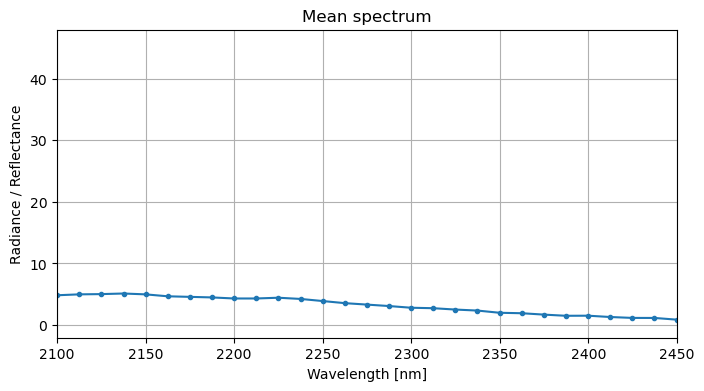

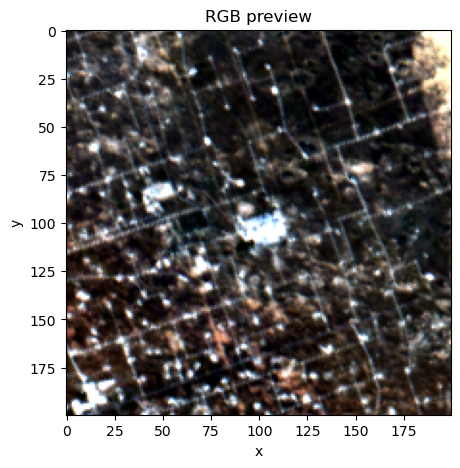

MODTRAN wavelength range: 380.00 - 2500.00 nm
alpha_grid: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]


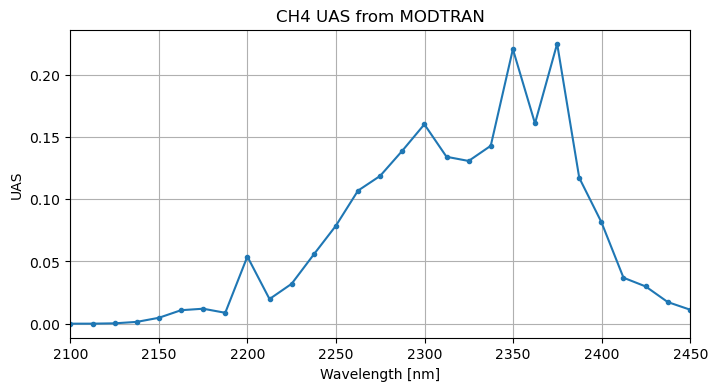

Selected cube shape: (200, 200, 29)
Valid pixels: 40000


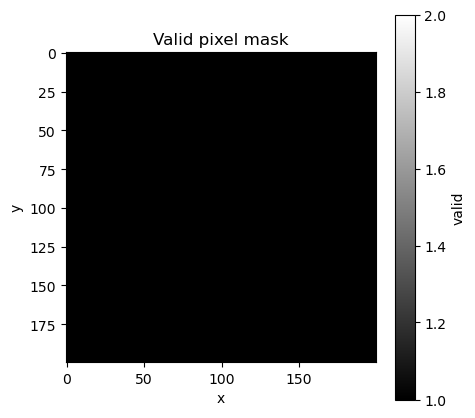

In [13]:

# ============================================
# 8. Load data and prepare cube/UAS
# ============================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load ROI spectra
roi_df, wavelengths, spectra = load_roi_spectra_csv(ROI_CSV)
cube, ys, xs = spectra_to_cube(roi_df, spectra)

print(f"ROI table shape: {roi_df.shape}")
print(f"Cube shape: {cube.shape}")
print(f"Wavelength range: {wavelengths[0]:.2f} - {wavelengths[-1]:.2f} nm")

# Quick visual checks
plot_mean_spectrum(cube, wavelengths, xlim=(WL_MIN, WL_MAX))

try:
    rgb = make_rgb_from_cube(cube, wavelengths)
    plt.figure(figsize=(5, 5))
    plt.imshow(rgb, origin="upper")
    plt.title("RGB preview")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()
except Exception as exc:
    print(f"RGB preview skipped: {exc}")

# Load MODTRAN and compute UAS
mod_wave, alpha_grid, mod_spectra = load_ch4_modtran_csv(MODTRAN_CSV)
print(f"MODTRAN wavelength range: {mod_wave[0]:.2f} - {mod_wave[-1]:.2f} nm")
print("alpha_grid:", alpha_grid)

mod_sensor = gaussian_srf_resample(
    mod_wave=mod_wave,
    mod_spectra=mod_spectra,
    sensor_wave=wavelengths,
    fwhm_nm=FWHM_NM,
)

uas_all, intercept = compute_uas_log_slope(
    alpha_grid=alpha_grid,
    spectra_grid=mod_sensor,
    alpha_min=UAS_ALPHA_MIN,
    alpha_max=UAS_ALPHA_MAX,
)

plot_uas(wavelengths, uas_all, title="CH4 UAS from MODTRAN", xlim=(WL_MIN, WL_MAX))

# Select SWIR / methane absorption range
cube_sel, wave_sel, band_sel = select_bands(cube, wavelengths, wl_min=WL_MIN, wl_max=WL_MAX)
uas_sel = uas_all[band_sel]

valid_mask = make_valid_pixel_mask(
    cube_sel,
    nodata_values=NODATA_VALUES,
    require_positive=REQUIRE_POSITIVE,
    min_valid_fraction=MIN_VALID_FRACTION,
)

print(f"Selected cube shape: {cube_sel.shape}")
print(f"Valid pixels: {int(np.sum(valid_mask))}")

plot_map(valid_mask.astype(float), title="Valid pixel mask", cmap="gray", colorbar_label="valid")


In [14]:

# ============================================
# 9. Run experiments
# ============================================

results = {}

for name, cfg in EXPERIMENTS.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {name}")
    print("=" * 80)

    res = run_iterative_mf_with_optional_destriping(
        cube=cube_sel,
        uas=uas_sel,
        valid_mask=valid_mask,
        initial_background_mask=None,
        n_iter=N_ITER,
        nsigma=NSIGMA,
        reg=REG,
        rcond=RCOND,
        min_background_pixels=None,
        destripe_when=cfg.get("destripe_when", "none"),
        destripe_params=cfg.get("destripe_params", None),
        verbose=True,
    )
    results[name] = res

summary_df = summarize_results_table(results)
summary_df



Running experiment: baseline_no_destripe
iter 01 | bg= 40000 | thr=+1.017654e-01 | med=-6.808986e-05 | rstd=3.394449e-02 | plume=   123 | destripe=False | directions=[]
iter 02 | bg= 39877 | thr=+9.632958e-02 | med=-4.771383e-05 | rstd=3.212576e-02 | plume=   214 | destripe=False | directions=[]
iter 03 | bg= 39786 | thr=+9.543942e-02 | med=+2.487352e-04 | rstd=3.173023e-02 | plume=   296 | destripe=False | directions=[]
iter 04 | bg= 39704 | thr=+9.493795e-02 | med=+3.956768e-04 | rstd=3.151409e-02 | plume=   360 | destripe=False | directions=[]
iter 05 | bg= 39640 | thr=+9.434170e-02 | med=+5.526205e-04 | rstd=3.126303e-02 | plume=   408 | destripe=False | directions=[]

Running experiment: median_yx_final_only
iter 01 | bg= 40000 | thr=+1.017654e-01 | med=-6.808986e-05 | rstd=3.394449e-02 | plume=   123 | destripe=False | directions=[]
iter 02 | bg= 39877 | thr=+9.632958e-02 | med=-4.771383e-05 | rstd=3.212576e-02 | plume=   214 | destripe=False | directions=[]
iter 03 | bg= 39786 

,name,destripe_when,method,directions,smooth_half_window,exclude_mode,converged_iter,threshold,median,robust_std,plume_pixels,valid_pixels
0,baseline_no_destripe,none,None,y_minus_x,NaN,None,None,0.094342,0.000553,0.031263,408,40000
1,median_yx_final_only,final_only,median,y_minus_x,0.0,robust_high,None,0.086959,0.000197,0.028921,296,40000
2,median_yx_each_iter,each_iter,median,y_minus_x,0.0,robust_high,None,0.088658,-0.000023,0.029560,246,40000
3,median_yx_then_ynegx_final_only,final_only,median,y_minus_x -> y_plus_x,0.0,robust_high,None,0.085508,0.000181,0.028442,314,40000
4,median_yx_then_ynegx_each_iter,each_iter,median,y_minus_x -> y_plus_x,0.0,robust_high,None,0.086222,0.000024,0.028733,263,40000
5,mean_yx_then_ynegx_each_iter,each_iter,mean,y_minus_x -> y_plus_x,0.0,robust_high,None,0.087617,0.000011,0.029202,234,40000
6,trimmed_mean_yx_then_ynegx_each_iter,each_iter,trimmed_mean,y_minus_x -> y_plus_x,0.0,robust_high,None,0.087358,0.000233,0.029042,248,40000
7,mode_yx_then_ynegx_each_iter,each_iter,mode,y_minus_x -> y_plus_x,0.0,robust_high,None,0.101430,-0.000792,0.034074,250,40000
8,median_yx_then_ynegx_iter_3_to_5,"[3, 4, 5]",median,y_minus_x -> y_plus_x,0.0,robust_high,None,0.086237,0.000027,0.028737,264,40000


,name,destripe_when,method,directions,smooth_half_window,exclude_mode,converged_iter,threshold,median,robust_std,plume_pixels,valid_pixels
0,baseline_no_destripe,none,None,y_minus_x,NaN,None,None,0.094342,0.000553,0.031263,408,40000
1,median_yx_final_only,final_only,median,y_minus_x,0.0,robust_high,None,0.086959,0.000197,0.028921,296,40000
2,median_yx_each_iter,each_iter,median,y_minus_x,0.0,robust_high,None,0.088658,-0.000023,0.029560,246,40000
3,median_yx_then_ynegx_final_only,final_only,median,y_minus_x -> y_plus_x,0.0,robust_high,None,0.085508,0.000181,0.028442,314,40000
4,median_yx_then_ynegx_each_iter,each_iter,median,y_minus_x -> y_plus_x,0.0,robust_high,None,0.086222,0.000024,0.028733,263,40000
5,mean_yx_then_ynegx_each_iter,each_iter,mean,y_minus_x -> y_plus_x,0.0,robust_high,None,0.087617,0.000011,0.029202,234,40000
6,trimmed_mean_yx_then_ynegx_each_iter,each_iter,trimmed_mean,y_minus_x -> y_plus_x,0.0,robust_high,None,0.087358,0.000233,0.029042,248,40000
7,mode_yx_then_ynegx_each_iter,each_iter,mode,y_minus_x -> y_plus_x,0.0,robust_high,None,0.101430,-0.000792,0.034074,250,40000
8,median_yx_then_ynegx_iter_3_to_5,"[3, 4, 5]",median,y_minus_x -> y_plus_x,0.0,robust_high,None,0.086237,0.000027,0.028737,264,40000


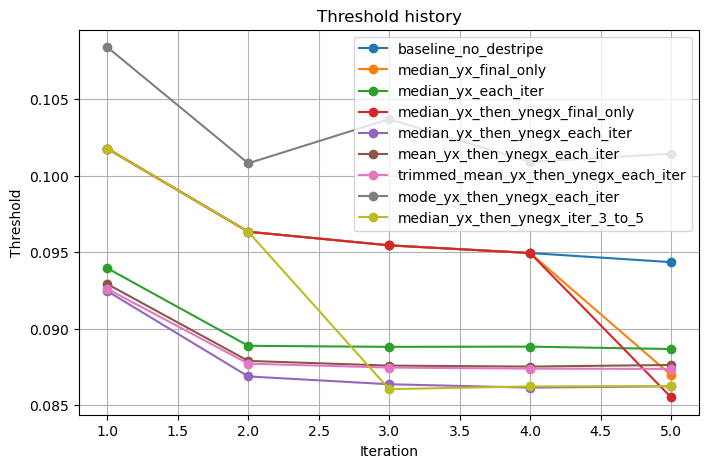

C:\Users\yudon\AppData\Local\Temp\ipykernel_3776\2236398326.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


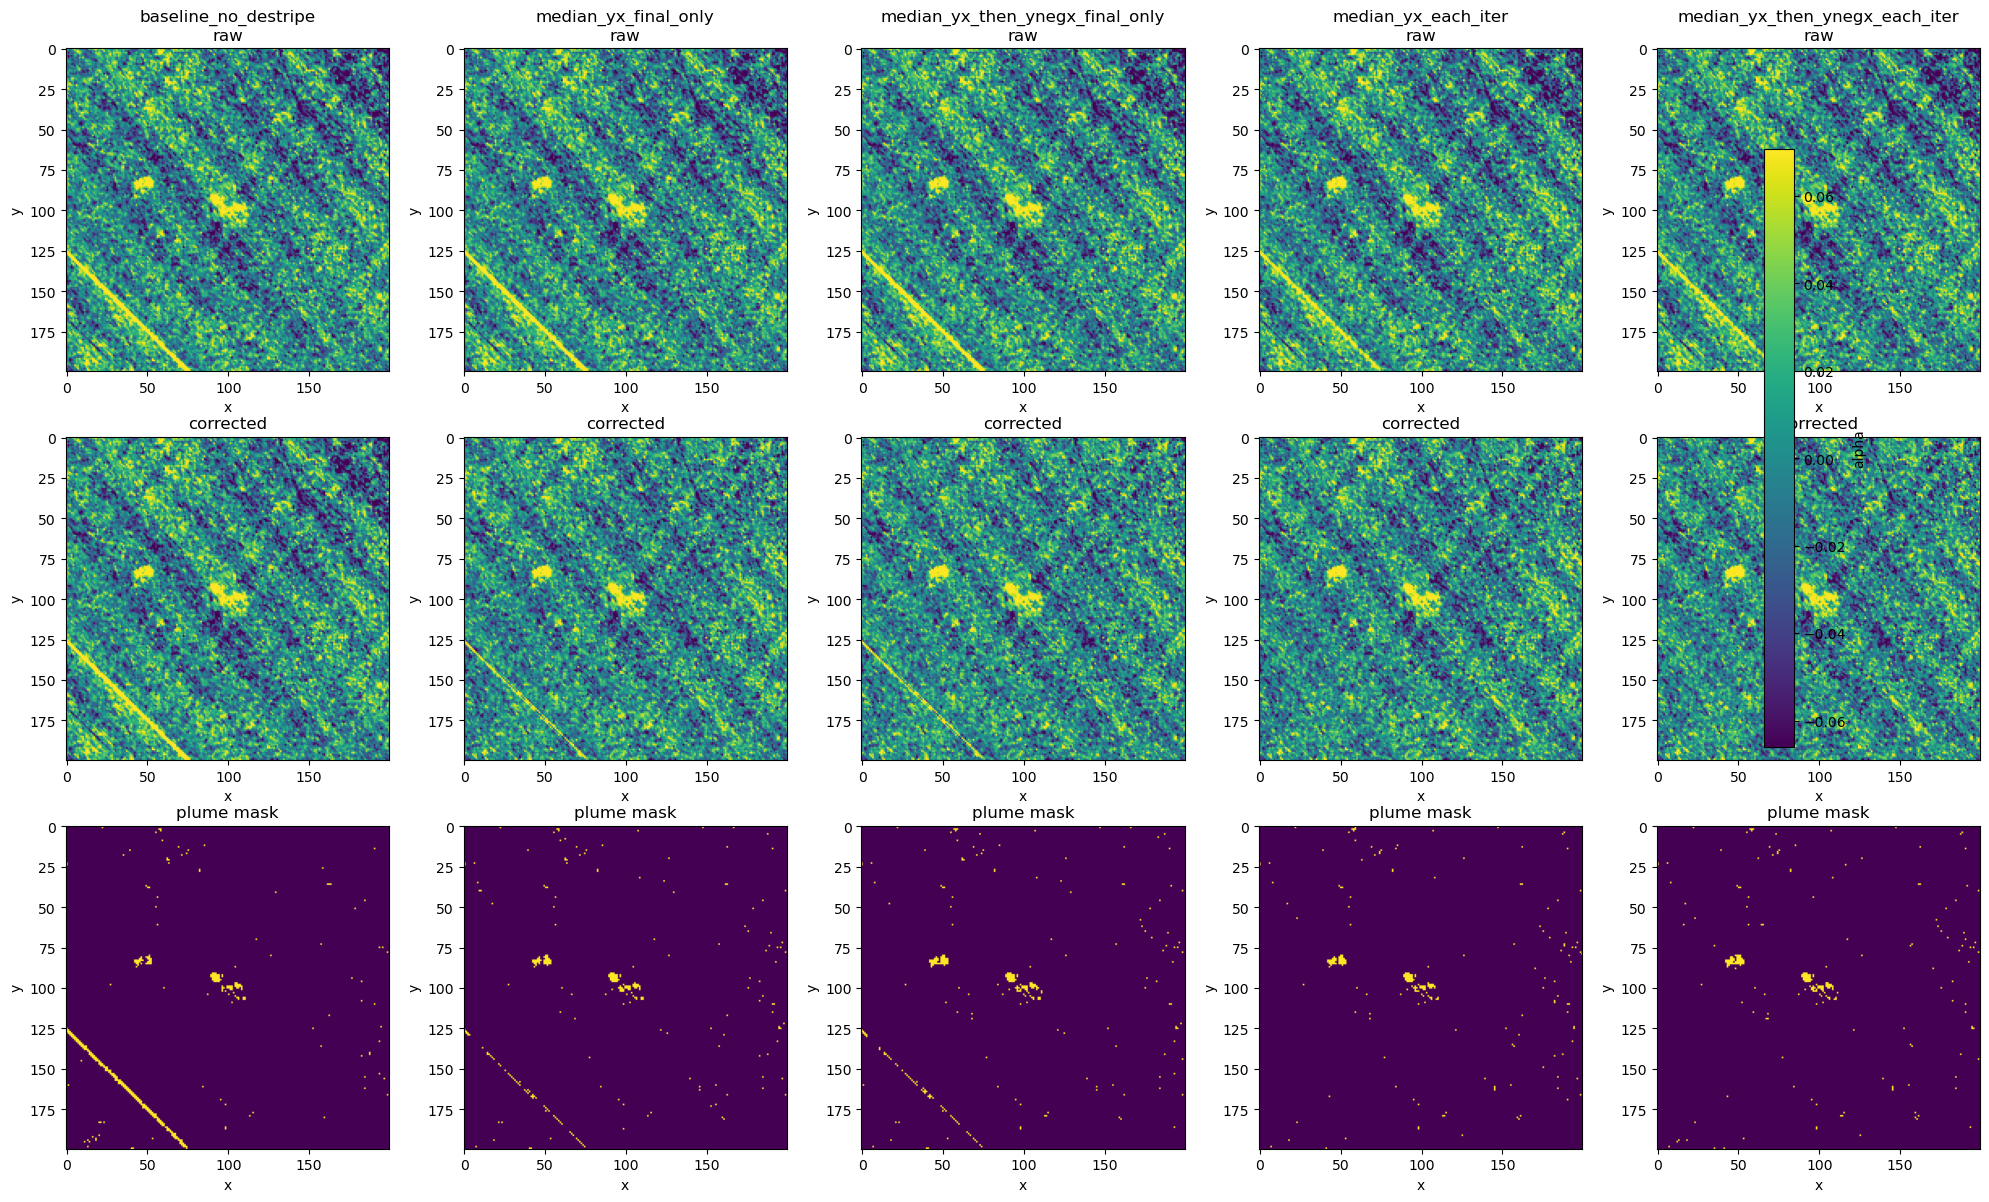

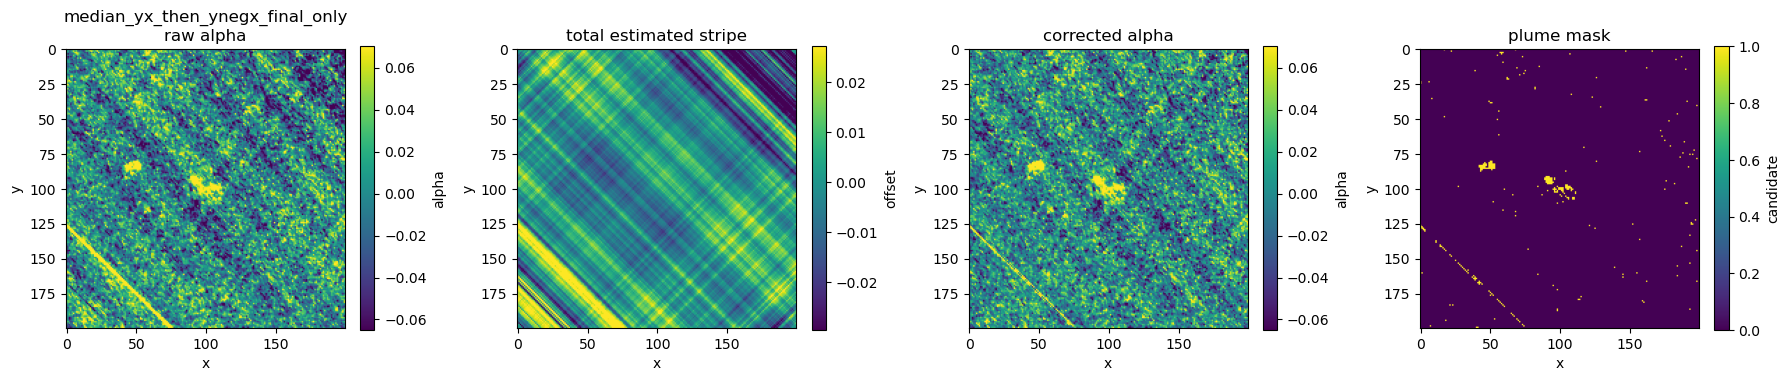

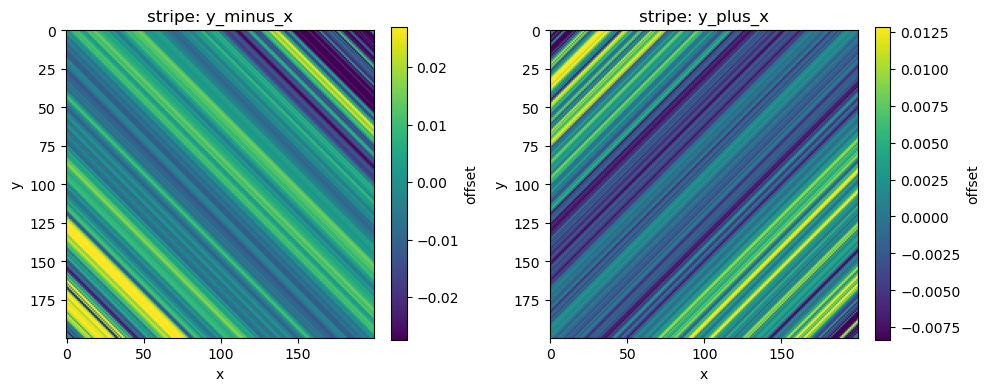

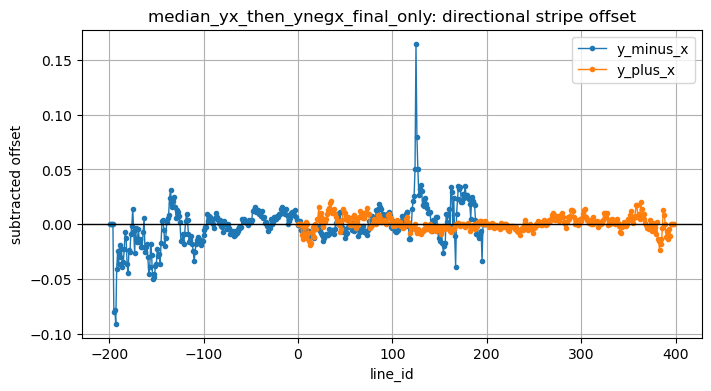

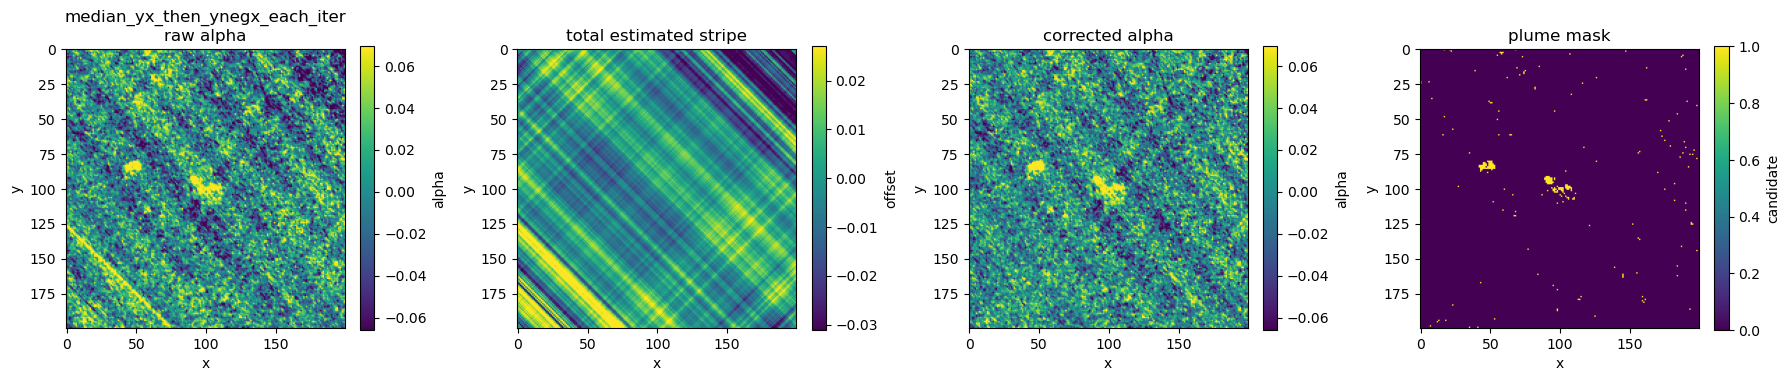

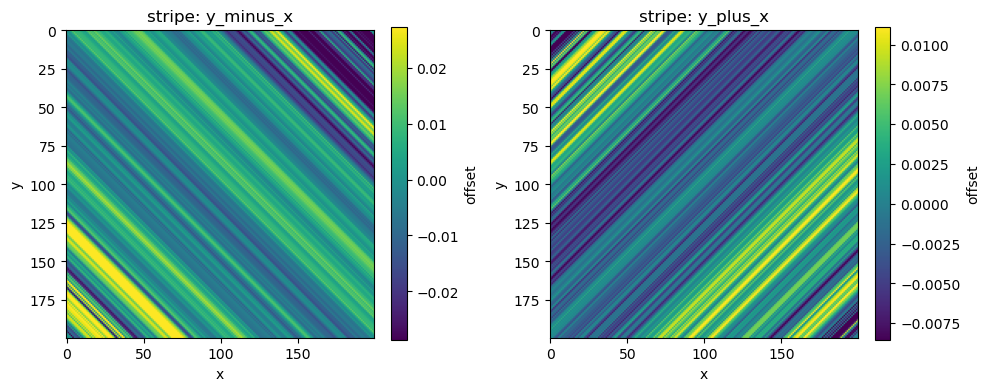

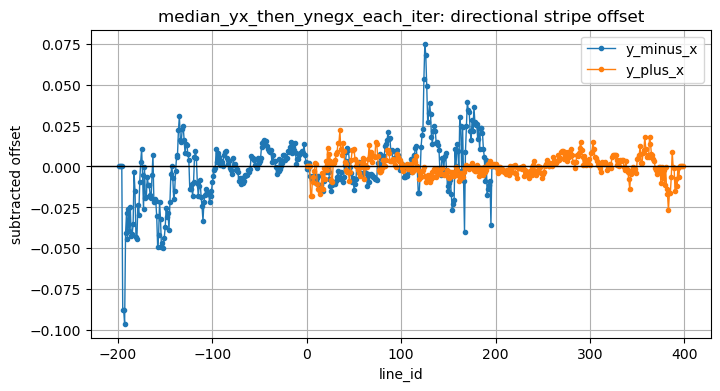

In [15]:
# ============================================
# 10. Compare results
# ============================================

# 一覧表
summary_df = summarize_results_table(results)
display(summary_df)

# threshold の履歴
plot_threshold_histories(results)

# まず見るべき比較
primary_names = [
    "baseline_no_destripe",
    "median_yx_final_only",
    "median_yx_then_ynegx_final_only",
    "median_yx_each_iter",
    "median_yx_then_ynegx_each_iter",
]
primary_names = [name for name in primary_names if name in results]
plot_experiment_grid(results, names=primary_names)

# 個別に詳しく見る例
plot_single_result(results["median_yx_then_ynegx_final_only"], title_prefix="median_yx_then_ynegx_final_only")
plot_single_result(results["median_yx_then_ynegx_each_iter"], title_prefix="median_yx_then_ynegx_each_iter")



In [16]:
# ============================================
# 11. Save selected outputs
# ============================================

# 保存したい case を選ぶ。まずは y=x のみと、y=x -> y=-x の2方向版を比較するのがおすすめ。
cases_to_save = [
    "median_yx_final_only",
    "median_yx_then_ynegx_final_only",
    "median_yx_then_ynegx_each_iter",
]

for case_name in cases_to_save:
    if case_name in results:
        save_case_outputs(
            result=results[case_name],
            case_name=case_name,
            output_dir=OUTPUT_DIR,
            ys=ys,
            xs=xs,
        )
        print(f"Saved: {case_name}")

# summary も保存
summarize_results_table(results).to_csv(OUTPUT_DIR / "experiment_summary.csv", index=False)
np.save(OUTPUT_DIR / "selected_wavelengths.npy", wave_sel)
np.save(OUTPUT_DIR / "selected_uas.npy", uas_sel)

print(f"All selected outputs were saved to: {OUTPUT_DIR.resolve()}")



Saved: median_yx_final_only
Saved: median_yx_then_ynegx_final_only
Saved: median_yx_then_ynegx_each_iter
All selected outputs were saved to: D:\research\code\outputs_two_direction_diagonal_destripe


## 使い方の目安

### 1. 今回の本命ケース

まずは以下を比較してください。

- `baseline_no_destripe`
- `median_yx_final_only`
- `median_yx_then_ynegx_final_only`
- `median_yx_then_ynegx_each_iter`

`median_yx_then_ynegx_*` が、今回の **y=x 方向で補正した後に y=-x 方向で補正する**ケースです。

### 2. 補正方向の指定

2方向補正はここで指定しています。

```python
"directions": ["y_minus_x", "y_plus_x"]
```

意味は以下です。

- `"y_minus_x"`: `row - col = const`、つまり画像上の `y=x` 方向の線
- `"y_plus_x"`: `row + col = const`、つまり画像上の `y=-x` 方向の線

順番を逆にしたい場合は、

```python
"directions": ["y_plus_x", "y_minus_x"]
```

としてください。

### 3. final_only と each_iter の違い

`final_only` は、Iterative MF の背景更新には補正を入れず、最後の alpha map だけを補正します。線が明確に消えるかを見るには一番わかりやすいです。

`each_iter` は、各 iteration の plume 判定前に補正を入れます。つまり次の背景 mask 更新にも影響します。線状 artifact が plume candidate として背景から除外されてしまう場合、こちらの方が効く可能性があります。

### 4. 2方向補正が強すぎる場合

2方向にすると補正が強くなり、本物の plume も削る可能性があります。その場合は以下を試してください。

```python
"exclude_mode": "robust_high"
```

から

```python
"exclude_mode": "none"
```

に変える、または `final_only` を優先して使う、という順で確認するとよいです。

### 5. diagonal offset がギザギザする場合

`DEFAULT_DESTRIPE_PARAMS["smooth_half_window"]` を `1` または `2` にして試してください。強くしすぎると本来の局所変化もならされます。

